In [1]:
import pandas as pd
import numpy as np
import optuna
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

SEED = 1234  # Fijar semilla para reproducibilidad
np.random.seed(SEED)

# 1. Cargar y preparar los datos
datos = pd.read_csv("data/Temp_Asu20092021.csv")

# Convertir 'Fecha' a tipo datetime y establecerla como índice
datos['Fecha'] = pd.to_datetime(datos['Fecha'])
datos.set_index('Fecha', inplace=True)

# Filtrar datos desde 2019 y eliminar valores faltantes
datos = datos[datos.index.year >= 2019].dropna()

# Calcular percentiles diarios
percentiles_diarios = datos.resample('D')['Temperatura'].agg(
    Percentil_95=lambda x: np.percentile(x, 95),
    Mediana=lambda x: np.percentile(x, 50),
    Percentil_5=lambda x: np.percentile(x, 5)
)

# Crear variables objetivo (desplazadas un día hacia adelante)
percentiles_diarios['Mediana_next'] = percentiles_diarios['Mediana'].shift(-1)

# Eliminar filas con valores faltantes
percentiles_diarios.dropna(inplace=True)

# Definir variables predictoras (X) y objetivo (y)
X = percentiles_diarios[['Mediana']]
y = percentiles_diarios['Mediana_next']

# Dividir en conjuntos de entrenamiento y validación
split_index = int(len(X) * 0.8)
X_train, X_valid = X.iloc[:split_index].values, X.iloc[split_index:].values
y_train, y_valid = y.iloc[:split_index].values, y.iloc[split_index:].values


[I 2024-10-17 15:42:31,417] A new study created in memory with name: no-name-9a02ff40-af2a-4d50-b925-a29dcc2e4b56
h:\Anaconda\envs\IA\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
[I 2024-10-17 15:42:31,511] Trial 0 finished with value: 5.688419556945544 and parameters: {'p': 1, 'd': 1, 'q': 2}. Best is trial 0 with value: 5.688419556945544.
[I 2024-10-17 15:42:32,158] Trial 1 finished with value: 7.686719923863981 and parameters: {'p': 4, 'd': 2, 'q': 1}. Best is trial 0 with value: 5.688419556945544.
h:\Anaconda\envs\IA\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
[I 2024-10-17 15:42:32,757] Trial 2 finished with value: 7.16442484749821 and parameters: {'p': 1, '

Mejores Hiperparámetros: {'p': 5, 'd': 0, 'q': 1}


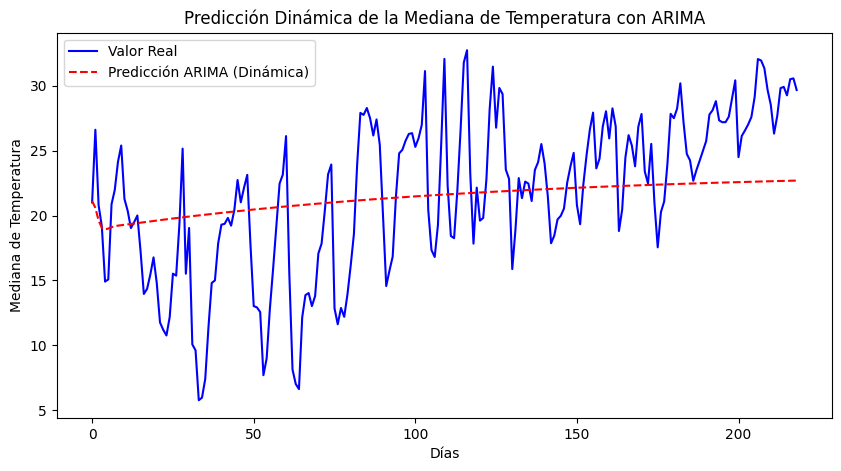

In [2]:

# 2. Definir la función objetivo para Optuna
def objective(trial):
    # Sugerir hiperparámetros
    p = trial.suggest_int('p', 0, 5)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 5)

    try:
        # Ajustar el modelo ARIMA en el conjunto de entrenamiento
        model = ARIMA(y_train, order=(p, d, q))
        model_fit = model.fit()

        # Predecir en el conjunto de validación
        y_pred = model_fit.forecast(steps=len(y_valid))
        mae = mean_absolute_error(y_valid, y_pred)
    except Exception as e:
        print(f"Error en la iteración: {e}")
        return float('inf')

    return mae

# 3. Optimización con Optuna
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.RandomSampler(seed=SEED))
study.optimize(objective, n_trials=50)

# 4. Mostrar los mejores hiperparámetros
best_params = study.best_params
print("Mejores Hiperparámetros:", best_params)

# Entrenar el modelo ARIMA una vez con el conjunto de entrenamiento
model = ARIMA(y_train, order=(best_params['p'], best_params['d'], best_params['q']))
model_fit = model.fit()
# 6. Predecir en el conjunto de validación sin ciclo for
y_pred = model_fit.forecast(steps=len(y_valid))

# 7. Evaluar el modelo final
mae_final = mean_absolute_error(y_valid, y_pred)
# Graficar las predicciones dinámicas
plt.figure(figsize=(10, 5))
plt.plot(y_valid, label='Valor Real', color='blue')
plt.plot(y_pred, label='Predicción ARIMA (Dinámica)', linestyle='--', color='red')
plt.xlabel('Días')
plt.ylabel('Mediana de Temperatura')
plt.title('Predicción Dinámica de la Mediana de Temperatura con ARIMA')
plt.legend()
plt.show()

[I 2024-10-17 15:46:32,615] A new study created in memory with name: no-name-a2fd230f-d663-405b-80c0-5b9809452344
h:\Anaconda\envs\IA\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
[I 2024-10-17 15:46:34,467] Trial 0 finished with value: 2.2938246429846942 and parameters: {'p': 1, 'd': 1, 'q': 2}. Best is trial 0 with value: 2.2938246429846942.
[I 2024-10-17 15:46:37,407] Trial 1 finished with value: 2.3444107805231944 and parameters: {'p': 4, 'd': 2, 'q': 1}. Best is trial 0 with value: 2.2938246429846942.
h:\Anaconda\envs\IA\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
[I 2024-10-17 15:46:40,587] Trial 2 finished with value: 2.3790634092639245 and parameters: {'p'

Mejores Hiperparámetros: {'p': 2, 'd': 0, 'q': 1}
MAE Dinámico: 2.22


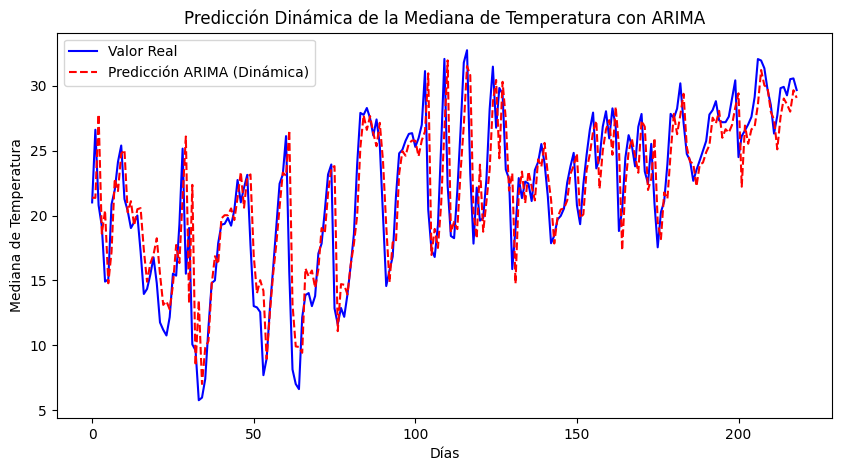

In [5]:

# 2. Definir la función objetivo para Optuna
def objective(trial):
    # Sugerir hiperparámetros
    p = trial.suggest_int('p', 0, 5)
    d = trial.suggest_int('d', 0, 2)
    q = trial.suggest_int('q', 0, 5)

    try:
        # Ajustar el modelo ARIMA en el conjunto de entrenamiento
        model = ARIMA(y_train, order=(p, d, q))
        model_fit = model.fit()

        # Predecir en el conjunto de validación
 
        # Predecir sobre el conjunto de validación usando predicción dinámica
        history = list(y_train)
        predictions = []

        for t in range(len(y_valid)):
            yhat = model_fit.forecast(steps=1)[0]  # Predecir un paso adelante
            predictions.append(yhat)

            # Actualizar el historial con el valor real
            history.append(y_valid[t])
            model_fit = model_fit.append([y_valid[t]], refit=False)  # Sin reentrenar
            # Calcular el error de validación
        mae = mean_absolute_error(y_valid, predictions)
    except Exception as e:
        print(f"Error en la iteración: {e}")
        return float('inf')

    return mae

# 3. Optimización con Optuna
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.RandomSampler(seed=SEED))
study.optimize(objective, n_trials=50)

# 4. Mostrar los mejores hiperparámetros
best_params = study.best_params
print("Mejores Hiperparámetros:", best_params)


# Entrenar el modelo ARIMA una vez con el conjunto de entrenamiento
model = ARIMA(y_train, order=(best_params['p'], best_params['d'], best_params['q']))
model_fit = model.fit()

# Hacer predicciones dinámicas paso a paso usando el modelo ajustado
history = list(y_train)  # Inicializar con los datos históricos
predictions = []

for t in range(len(y_valid)):
    # Predecir el siguiente valor basándose en la historia acumulada
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat)

    # Actualizar el historial con el valor real del conjunto de validación
    history.append(y_valid[t])

    # Actualizar el modelo internamente con el nuevo dato real
    model_fit = model_fit.append([y_valid[t]], refit=False)

# Evaluar el desempeño
mae_dynamic = mean_absolute_error(y_valid, predictions)
print(f'MAE Dinámico: {mae_dynamic:.2f}')

# Graficar las predicciones dinámicas
plt.figure(figsize=(10, 5))
plt.plot(y_valid, label='Valor Real', color='blue')
plt.plot(predictions, label='Predicción ARIMA (Dinámica)', linestyle='--', color='red')
plt.xlabel('Días')
plt.ylabel('Mediana de Temperatura')
plt.title('Predicción Dinámica de la Mediana de Temperatura con ARIMA')
plt.legend()
plt.show()